# KAIST one-window observability profiling

This notebook reproduces the observability processing of one 5-second KAIST window and measures execution time stage by stage.

Timed scientific path:

\[
\text{reference trajectory}
\rightarrow
\text{linearize factors}
\rightarrow
\text{whiten}
\rightarrow
\text{project trajectory+nuisance}
\rightarrow
F_C
\rightarrow
\text{metrics}.
\]

The notebook does not optimize anything. First we measure. If Python-heavy factor evaluation dominates, those kernels become candidates for a future `numerics_njitted.py`. Dense linear-algebra calls such as SVD, Cholesky, triangular solve, and matrix multiplication are already delegated to optimized libraries and should not be njitted merely because they appear in the profile.


In [2]:
from pathlib import Path
from collections import defaultdict
import cProfile
import inspect
import io
import pstats
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

ROOT = Path.cwd()

for candidate in (ROOT, *ROOT.parents):
    if (candidate / "src" / "obscalib").exists():
        ROOT = candidate
        break
else:
    raise FileNotFoundError("Could not locate the nn-obs-calib repository root containing src/obscalib.")

if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

from kaist_dataset import load_imus
from kaist_dataset.lidar import load_lidar_map_poses as load_lidar_map_pose_csv

from obscalib.config import WindowingConfig
from obscalib.data.adapter import PreprocessedCalibration, PreprocessedSensorStream, build_window_samples_from_preprocessed
from obscalib.data.structures import GeometryType, MeasurementType
from obscalib.observability.layout import CalibrationParameterLayout
from obscalib.observability.linearization import linearize_single_window
from obscalib.observability.matrix import compute_observability_matrix_single_window, fisher_information_from_projected_jacobian, project_calibration_jacobian
from obscalib.observability.metrics import compute_condition_number, compute_crlb, compute_numerical_rank, compute_singular_values
from obscalib.observability.numerics import ObservabilityNumericsConfig
from obscalib.observability.timebase import ReferenceTimebase
from obscalib.observability.whitening import whiten_window_linearization

DTYPE = torch.float64

print("Repository root:", ROOT)
print("PyTorch:", torch.__version__)
print("PyTorch CPU threads:", torch.get_num_threads())

Repository root: /home/camel/Skoltech/Mobile_Robotics_Lab/nn-obs-calib
PyTorch: 2.7.1+cu126
PyTorch CPU threads: 12


## Configuration

`WINDOW_START_OFFSET_S` is measured from the beginning of common IMU / left-LiDAR / right-LiDAR support. Change only this value to profile another part of the sequence.

In [3]:
SEQUENCE_NUMBER = 16
SEQUENCE_NAME = f"Urban{SEQUENCE_NUMBER:02d}"
SEQUENCE_SLUG = SEQUENCE_NAME.lower()

KAIST_DATASET_ROOT = Path("/mnt/d/Downloads/MobRobLab/KAISTDataset")
LIDAR_POSE_ROOT = Path("/home/camel/Skoltech/phd_proposal/data/KAISTDataset")

DATASET_ROOT = KAIST_DATASET_ROOT / SEQUENCE_NAME
SENSOR_DATA_ROOT = DATASET_ROOT / f"{SEQUENCE_SLUG}_data" / SEQUENCE_SLUG / "sensor_data"

LIDAR_SIDES = ("left", "right")
REFERENCE_LIDAR_SIDE = "left"
REFERENCE_LIDAR_STREAM_KEY = "lidar_left"
LIDAR_MAP_POSE_CSV_BY_SIDE = {side: LIDAR_POSE_ROOT / SEQUENCE_NAME / f"lidar_map_poses_vlp_{side}.csv" for side in LIDAR_SIDES}

WINDOW_DURATION_S = 5.0
WINDOW_START_OFFSET_S = 0.0
MAX_SAMPLES_PER_SENSOR = 700

LOAD_IMU_FREQUENCY_HZ = None
MAX_IMU_FILES = None

WARMUP_RUNS = 2
BENCHMARK_RUNS = 20
CPROFILE_TOP_N = 35

T_B_LL = np.array([[-0.514066, -0.702201, -0.492595, -0.440699], [0.486485, -0.711672, 0.506809, 0.397052], [-0.706447, 0.0208933, 0.707457, 1.90953], [0.0, 0.0, 0.0, 1.0]], dtype=float)
T_B_RL = np.array([[-0.512152, 0.699241, -0.498761, -0.449885], [-0.494811, -0.714859, -0.494104, -0.416713], [-0.702041, -0.0062642, 0.712109, 1.91294], [0.0, 0.0, 0.0, 1.0]], dtype=float)
T_B_LIDAR_BY_SIDE = {"left": T_B_LL, "right": T_B_RL}

T_I_B = np.array([[1.0, 0.0, 0.0, -0.07], [0.0, 1.0, 0.0, 0.0], [0.0, 0.0, 1.0, 1.7], [0.0, 0.0, 0.0, 1.0]], dtype=float)
T_B_I = np.linalg.inv(T_I_B)

GRAVITY_WORLD = torch.tensor([0.0, 0.0, 9.81], dtype=DTYPE)

GYRO_MEASUREMENT_COVARIANCE = torch.tensor([[2.96367932e-06, -1.94438078e-07, -4.83643437e-07], [-1.94438078e-07, 1.89162212e-06, 1.09062693e-07], [-4.83643437e-07, 1.09062693e-07, 1.88843506e-06]], dtype=DTYPE)
ACCEL_MEASUREMENT_COVARIANCE = torch.tensor([[4.85003041e-03, -9.25262862e-05, 2.14219676e-04], [-9.25262862e-05, 1.51980006e-03, -1.13182999e-03], [2.14219676e-04, -1.13182999e-03, 2.29777687e-03]], dtype=DTYPE)
LIDAR_SCAN_TO_MAP_ROTATION_COVARIANCE = torch.tensor([[1.10442767e-05, 9.46809587e-07, 3.78536515e-06], [9.46809587e-07, 3.35041997e-05, 1.90008728e-06], [3.78536515e-06, 1.90008728e-06, 1.10553483e-05]], dtype=DTYPE)
LIDAR_SCAN_TO_MAP_TRANSLATION_COVARIANCE = torch.tensor([[0.00843466, 0.00266052, 0.00702046], [0.00266052, 0.01444850, 0.00225705], [0.00702046, 0.00225705, 0.00704268]], dtype=DTYPE)

LIDAR_SCAN_TO_MAP_COVARIANCE = torch.zeros((6, 6), dtype=DTYPE)
LIDAR_SCAN_TO_MAP_COVARIANCE[:3, :3] = LIDAR_SCAN_TO_MAP_ROTATION_COVARIANCE
LIDAR_SCAN_TO_MAP_COVARIANCE[3:, 3:] = LIDAR_SCAN_TO_MAP_TRANSLATION_COVARIANCE
LIDAR_RELATIVE_RESIDUAL_COVARIANCE = 2.0 * LIDAR_SCAN_TO_MAP_COVARIANCE

print("Sequence:", SEQUENCE_NAME)
print("Window start offset [s]:", WINDOW_START_OFFSET_S)
print("Benchmark runs:", BENCHMARK_RUNS)

Sequence: Urban16
Window start offset [s]: 0.0
Benchmark runs: 20


## Small data helpers

These are setup helpers only. Their execution is not included in the per-window observability benchmark.

In [4]:
def load_successful_lidar_map_poses(csv_path: Path) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Load successful finite T_W_L scan-to-map poses and retain original CSV row indices."""

    timestamps_s, poses_T_W_L, dataframe = load_lidar_map_pose_csv(csv_path)
    timestamps_s = np.asarray(timestamps_s, dtype=float).reshape(-1)
    poses_T_W_L = np.asarray(poses_T_W_L, dtype=float)
    success_mask = dataframe["success"].to_numpy(dtype=bool) if "success" in dataframe.columns else np.ones(len(dataframe), dtype=bool)
    finite_mask = np.all(np.isfinite(poses_T_W_L[:, :3, :]), axis=(1, 2))
    mask = success_mask & finite_mask
    source_indices = np.flatnonzero(mask)
    timestamps_s = timestamps_s[mask]
    poses_T_W_L = poses_T_W_L[mask]

    if len(timestamps_s) < 2 or np.any(np.diff(timestamps_s) <= 0.0):
        raise ValueError(f"Invalid successful LiDAR pose sequence: {csv_path}")

    return timestamps_s, poses_T_W_L, source_indices


def build_relative_lidar_intervals(timestamps_s: np.ndarray, poses_T_W_L: np.ndarray, source_indices: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Build relative LiDAR measurements only between adjacent original scan rows."""

    adjacent_mask = np.diff(source_indices) == 1
    start_poses = poses_T_W_L[:-1][adjacent_mask]
    end_poses = poses_T_W_L[1:][adjacent_mask]

    return np.linalg.inv(start_poses) @ end_poses, timestamps_s[:-1][adjacent_mask], timestamps_s[1:][adjacent_mask]


def nearest_pose_indices(source_timestamps_s: np.ndarray, query_timestamps_s: np.ndarray, tolerance_s: float = 5e-5) -> np.ndarray:
    """Match reference timestamps to scan-to-map poses."""

    right_indices = np.clip(np.searchsorted(source_timestamps_s, query_timestamps_s, side="left"), 0, len(source_timestamps_s) - 1)
    left_indices = np.clip(right_indices - 1, 0, len(source_timestamps_s) - 1)
    indices = np.where(np.abs(source_timestamps_s[right_indices] - query_timestamps_s) < np.abs(source_timestamps_s[left_indices] - query_timestamps_s), right_indices, left_indices)
    errors = np.abs(source_timestamps_s[indices] - query_timestamps_s)

    if np.any(errors > tolerance_s):
        worst = int(np.argmax(errors))
        raise ValueError(f"Could not match reference LiDAR timestamp {query_timestamps_s[worst]:.9f}; nearest error is {errors[worst]:.6g} s.")

    return indices


def build_reference_trajectory(window, window_start_time_s: float, lidar_map_timestamps_s: np.ndarray, lidar_map_poses_T_W_L: np.ndarray, T_B_L: np.ndarray) -> tuple[ReferenceTimebase, torch.Tensor]:
    """Build the nominal body trajectory at all unique reference LiDAR interval endpoints."""

    lidar_stream = window.streams[REFERENCE_LIDAR_STREAM_KEY]

    if lidar_stream.interval_start_timestamps is None:
        raise ValueError("Reference LiDAR stream must be interval-valued.")

    reference_timestamps = torch.unique(torch.cat((lidar_stream.interval_start_timestamps, lidar_stream.timestamps)), sorted=True).to(device="cpu", dtype=DTYPE)
    reference_timebase = ReferenceTimebase(stream_key=REFERENCE_LIDAR_STREAM_KEY, timestamps=reference_timestamps)
    reference_timebase.validate()

    absolute_reference_timestamps_s = window_start_time_s + reference_timestamps.detach().cpu().numpy()
    pose_indices = nearest_pose_indices(lidar_map_timestamps_s, absolute_reference_timestamps_s)
    T_W_L = lidar_map_poses_T_W_L[pose_indices]
    T_W_B = T_W_L @ np.linalg.inv(T_B_L)
    T_W_B_local = T_W_B.copy()
    T_W_B_local[:, :3, 3] -= T_W_B_local[0, :3, 3].copy()

    return reference_timebase, torch.as_tensor(T_W_B_local, dtype=DTYPE, device="cpu")

## Load the sequence and build exactly one 5-second window

Dataset loading is intentionally outside the timed section. The selected window start is known exactly, so there is no retained-window-index ambiguity.

In [5]:
imu_streams = load_imus(SENSOR_DATA_ROOT, target_frequency_hz=LOAD_IMU_FREQUENCY_HZ, max_files=MAX_IMU_FILES)

if not imu_streams:
    raise ValueError(f"No KAIST IMU streams were found below {SENSOR_DATA_ROOT}.")

primary_imu_name = list(imu_streams.keys())[0]
primary_imu = imu_streams[primary_imu_name]

lidar_map_timestamps_s_by_side = {}
lidar_map_poses_T_W_L_by_side = {}
lidar_relative_poses_by_side = {}
lidar_interval_start_timestamps_s_by_side = {}
lidar_interval_end_timestamps_s_by_side = {}

for side in LIDAR_SIDES:
    timestamps_s, poses_T_W_L, source_indices = load_successful_lidar_map_poses(LIDAR_MAP_POSE_CSV_BY_SIDE[side])
    relative_poses, interval_starts, interval_ends = build_relative_lidar_intervals(timestamps_s, poses_T_W_L, source_indices)
    lidar_map_timestamps_s_by_side[side] = timestamps_s
    lidar_map_poses_T_W_L_by_side[side] = poses_T_W_L
    lidar_relative_poses_by_side[side] = relative_poses
    lidar_interval_start_timestamps_s_by_side[side] = interval_starts
    lidar_interval_end_timestamps_s_by_side[side] = interval_ends

streams = {
    "gyro": PreprocessedSensorStream(values=primary_imu.gyro_radps, timestamps_s=primary_imu.timestamps_s, measurement_type=MeasurementType.IMU_GYROSCOPE, geometry_type=GeometryType.VECTOR, calibration_key="imu"),
    "accel": PreprocessedSensorStream(values=primary_imu.accel_mps2, timestamps_s=primary_imu.timestamps_s, measurement_type=MeasurementType.IMU_ACCELEROMETER, geometry_type=GeometryType.VECTOR, calibration_key="imu"),
    "lidar_left": PreprocessedSensorStream(values=lidar_relative_poses_by_side["left"], timestamps_s=lidar_interval_end_timestamps_s_by_side["left"], interval_start_timestamps_s=lidar_interval_start_timestamps_s_by_side["left"], measurement_type=MeasurementType.LIDAR_POSE, geometry_type=GeometryType.SE3, calibration_key="lidar_left"),
    "lidar_right": PreprocessedSensorStream(values=lidar_relative_poses_by_side["right"], timestamps_s=lidar_interval_end_timestamps_s_by_side["right"], interval_start_timestamps_s=lidar_interval_start_timestamps_s_by_side["right"], measurement_type=MeasurementType.LIDAR_POSE, geometry_type=GeometryType.SE3, calibration_key="lidar_right"),
}

current_calibration = {
    "imu": PreprocessedCalibration(transform=T_B_I, time_offset_s=0.0),
    "lidar_left": PreprocessedCalibration(transform=T_B_LL, time_offset_s=0.0),
    "lidar_right": PreprocessedCalibration(transform=T_B_RL, time_offset_s=0.0),
}

common_start_time_s = max(float(primary_imu.timestamps_s[0]), float(lidar_interval_start_timestamps_s_by_side["left"][0]), float(lidar_interval_start_timestamps_s_by_side["right"][0]))
common_end_time_s = min(float(primary_imu.timestamps_s[-1]), float(lidar_interval_end_timestamps_s_by_side["left"][-1]), float(lidar_interval_end_timestamps_s_by_side["right"][-1]))

window_start_time_s = common_start_time_s + WINDOW_START_OFFSET_S
window_end_time_s = window_start_time_s + WINDOW_DURATION_S

if window_end_time_s > common_end_time_s:
    raise ValueError(f"Requested profiling window ends after common sensor support. Window end={window_end_time_s}, common end={common_end_time_s}.")

windowing_config = WindowingConfig(window_duration_s=WINDOW_DURATION_S, window_stride_s=WINDOW_DURATION_S, max_samples_per_sensor=MAX_SAMPLES_PER_SENSOR)
window_samples = build_window_samples_from_preprocessed(streams, current_calibration, windowing_config=windowing_config, start_time=window_start_time_s, end_time=window_end_time_s, dtype=DTYPE, timestamp_dtype=torch.float64)

if len(window_samples) != 1:
    raise ValueError(f"Expected exactly one complete profiling window at start {window_start_time_s:.6f}, received {len(window_samples)}. Choose another WINDOW_START_OFFSET_S if this interval contains a LiDAR gap.")

window = window_samples[0]

print("Window absolute start [s]:", window_start_time_s)
print("Window absolute end [s]:", window_end_time_s)
print()

for stream_key, stream in window.streams.items():
    print(f"{stream_key:12s}: {len(stream.timestamps):4d} measurements, values shape={tuple(stream.values.shape)}, interval-valued={stream.interval_start_timestamps is not None}")

Window absolute start [s]: 1524205126.7
Window absolute end [s]: 1524205131.7

gyro        :  500 measurements, values shape=(500, 3), interval-valued=False
accel       :  500 measurements, values shape=(500, 3), interval-valued=False
lidar_left  :   49 measurements, values shape=(49, 4, 4), interval-valued=True
lidar_right :   49 measurements, values shape=(49, 4, 4), interval-valued=True


## Scientific configuration and one untimed correctness pass

In [6]:
CALIBRATION_KEYS = ("imu", "lidar_left", "lidar_right")
calibration_layout = CalibrationParameterLayout.from_calibration_keys(CALIBRATION_KEYS)

residual_covariance_by_stream = {"gyro": GYRO_MEASUREMENT_COVARIANCE, "accel": ACCEL_MEASUREMENT_COVARIANCE, "lidar_left": LIDAR_RELATIVE_RESIDUAL_COVARIANCE, "lidar_right": LIDAR_RELATIVE_RESIDUAL_COVARIANCE}
gyro_bias_by_calibration_key = {"imu": torch.zeros(3, dtype=DTYPE)}
numerics = ObservabilityNumericsConfig(relative_tolerance=1e-10, parameter_scales=None)

linearization_parameters = inspect.signature(linearize_single_window).parameters
required_parameters = {"trajectory_poses", "residual_covariance_by_stream"}
missing_parameters = required_parameters - set(linearization_parameters)

if missing_parameters:
    raise RuntimeError(f"Local linearize_single_window() is older than this profiling notebook. Missing parameters: {sorted(missing_parameters)}.")

reference_timebase, trajectory_poses = build_reference_trajectory(window, window_start_time_s, lidar_map_timestamps_s_by_side[REFERENCE_LIDAR_SIDE], lidar_map_poses_T_W_L_by_side[REFERENCE_LIDAR_SIDE], T_B_LIDAR_BY_SIDE[REFERENCE_LIDAR_SIDE])

linearization_kwargs = {"trajectory_poses": trajectory_poses, "gyro_bias_by_calibration_key": gyro_bias_by_calibration_key, "residual_covariance_by_stream": residual_covariance_by_stream}

if "gravity_world" in linearization_parameters:
    linearization_kwargs["gravity_world"] = GRAVITY_WORLD

linearization = linearize_single_window(window.streams, window.metadata, window.current_calibration, calibration_layout, reference_timebase, **linearization_kwargs)
whitened = whiten_window_linearization(linearization)
projected_calibration_jacobian = project_calibration_jacobian(whitened, numerics)
fisher_information_matrix = fisher_information_from_projected_jacobian(projected_calibration_jacobian, numerics)
matrix_result = compute_observability_matrix_single_window(linearization, numerics)

singular_values = compute_singular_values(matrix_result, numerics)
rank = compute_numerical_rank(matrix_result, numerics)
condition_number = compute_condition_number(matrix_result, numerics)
crlb = compute_crlb(matrix_result, numerics)

print("Reference poses:", len(reference_timebase.timestamps))
print("Factors:", len(linearization.factors))
print("Whitened residual rows:", whitened.residual.shape[0])
print("Projected calibration Jacobian:", tuple(projected_calibration_jacobian.shape))
print("Fisher:", tuple(fisher_information_matrix.shape))
print("Rank:", rank)
print("Condition number:", float(condition_number))
print("CRLB output shape:", tuple(crlb.shape))

Reference poses: 50
Factors: 292
Whitened residual rows: 1164
Projected calibration Jacobian: (1164, 21)
Fisher: (21, 21)
Rank: 12
Condition number: inf
CRLB output shape: (21,)


## Timing utility

`benchmark()` performs untimed warmups and then repeated wall-clock measurements using `time.perf_counter_ns()`. Outputs are kept alive so the calls cannot be optimized away by Python-level dead-code elimination.

In [7]:
_benchmark_sink = []


def benchmark(name: str, function, warmup_runs: int = WARMUP_RUNS, benchmark_runs: int = BENCHMARK_RUNS) -> dict[str, float]:
    """Benchmark one callable and return wall-clock statistics in milliseconds."""

    for _ in range(warmup_runs):
        _benchmark_sink.append(function())

    durations_ms = np.empty(benchmark_runs, dtype=float)

    for run_index in range(benchmark_runs):
        start_ns = time.perf_counter_ns()
        result = function()
        end_ns = time.perf_counter_ns()
        _benchmark_sink.append(result)
        durations_ms[run_index] = (end_ns - start_ns) * 1e-6

    return {"stage": name, "mean_ms": float(np.mean(durations_ms)), "median_ms": float(np.median(durations_ms)), "min_ms": float(np.min(durations_ms)), "p90_ms": float(np.percentile(durations_ms, 90.0)), "max_ms": float(np.max(durations_ms)), "std_ms": float(np.std(durations_ms))}

## Benchmark individual stages

The inputs to each stage are precomputed once, so the measurements isolate the function itself rather than recursively including all previous stages.

In [8]:
timing_rows = []

timing_rows.append(benchmark("reference trajectory", lambda: build_reference_trajectory(window, window_start_time_s, lidar_map_timestamps_s_by_side[REFERENCE_LIDAR_SIDE], lidar_map_poses_T_W_L_by_side[REFERENCE_LIDAR_SIDE], T_B_LIDAR_BY_SIDE[REFERENCE_LIDAR_SIDE])))
timing_rows.append(benchmark("linearize_single_window", lambda: linearize_single_window(window.streams, window.metadata, window.current_calibration, calibration_layout, reference_timebase, **linearization_kwargs)))
timing_rows.append(benchmark("whiten_window_linearization", lambda: whiten_window_linearization(linearization)))
timing_rows.append(benchmark("project_calibration_jacobian", lambda: project_calibration_jacobian(whitened, numerics)))
timing_rows.append(benchmark("fisher_from_projected_jacobian", lambda: fisher_information_from_projected_jacobian(projected_calibration_jacobian, numerics)))
timing_rows.append(benchmark("full Fisher pipeline", lambda: compute_observability_matrix_single_window(linearization, numerics)))
timing_rows.append(benchmark("metric: singular values", lambda: compute_singular_values(matrix_result, numerics)))
timing_rows.append(benchmark("metric: numerical rank", lambda: compute_numerical_rank(matrix_result, numerics)))
timing_rows.append(benchmark("metric: condition number", lambda: compute_condition_number(matrix_result, numerics)))
timing_rows.append(benchmark("metric: CRLB", lambda: compute_crlb(matrix_result, numerics)))

timings = pd.DataFrame(timing_rows).sort_values("median_ms", ascending=False).reset_index(drop=True)
display(timings)

,stage,mean_ms,median_ms,min_ms,p90_ms,max_ms,std_ms
0,linearize_single_window,1553.248250,1526.105338,1292.280853,1683.934719,2180.278708,180.053801
1,full Fisher pipeline,1515.561537,811.915186,510.334531,3104.234988,5393.150110,1387.165910
2,whiten_window_linearization,959.114133,566.408887,256.573934,1773.722177,2513.946430,700.762028
3,project_calibration_jacobian,731.924870,398.562434,232.425409,2006.365356,2364.479967,684.600887
4,metric: CRLB,2.322363,1.883439,0.584749,4.475798,8.362120,1.735601
5,metric: singular values,1.813472,1.724223,0.711286,2.668169,4.512892,0.948912
6,metric: condition number,1.797129,1.695327,0.875840,2.475082,3.929090,0.687841
7,metric: numerical rank,1.613400,1.479988,0.674781,2.473261,3.315947,0.686855
8,fisher_from_projected_jacobian,1.357007,1.263441,0.700950,1.802422,2.389234,0.428269
9,reference trajectory,1.133637,0.624227,0.293341,1.043300,8.762767,1.847251


## Visual bottleneck summary

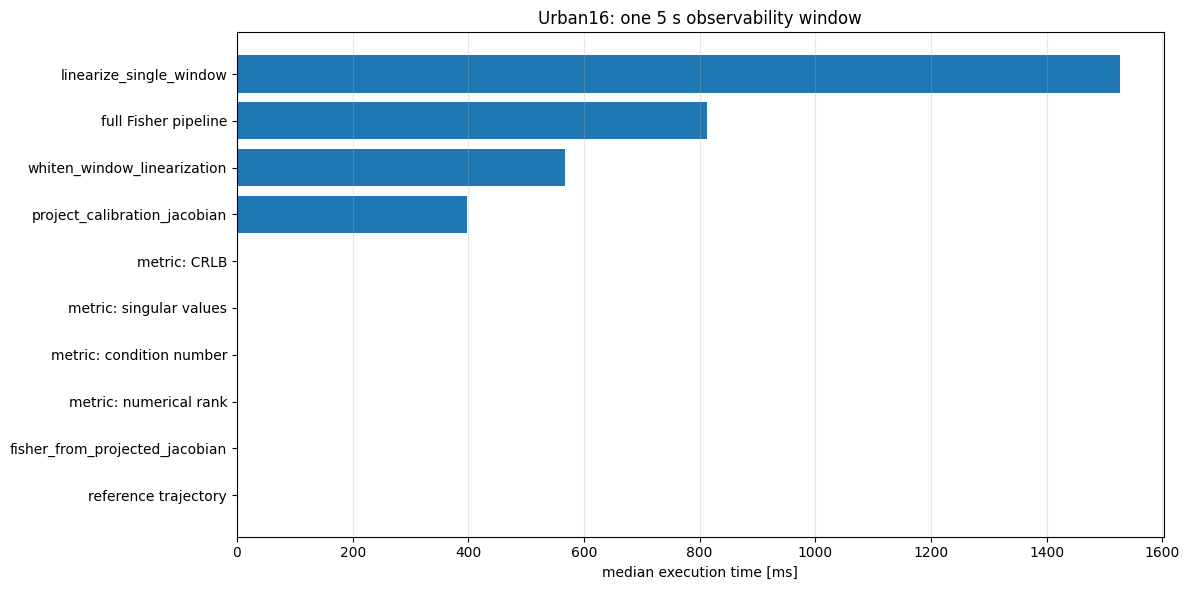

In [9]:
fig, ax = plt.subplots(figsize=(12, 6))
ordered = timings.sort_values("median_ms", ascending=True)
ax.barh(ordered["stage"], ordered["median_ms"])
ax.set_xlabel("median execution time [ms]")
ax.set_title(f"{SEQUENCE_NAME}: one {WINDOW_DURATION_S:g} s observability window")
ax.grid(True, axis="x", alpha=0.3)
fig.tight_layout()
plt.show()

## Time one complete observability pass

This cell measures the actual sequential path including reference-trajectory construction and all four requested metrics. It is intentionally separate from the isolated-stage timings.

In [10]:
def process_one_window_complete():
    """Run the complete one-window observability path and return all final scientific outputs."""

    local_reference_timebase, local_trajectory_poses = build_reference_trajectory(window, window_start_time_s, lidar_map_timestamps_s_by_side[REFERENCE_LIDAR_SIDE], lidar_map_poses_T_W_L_by_side[REFERENCE_LIDAR_SIDE], T_B_LIDAR_BY_SIDE[REFERENCE_LIDAR_SIDE])
    local_kwargs = {"trajectory_poses": local_trajectory_poses, "gyro_bias_by_calibration_key": gyro_bias_by_calibration_key, "residual_covariance_by_stream": residual_covariance_by_stream}

    if "gravity_world" in linearization_parameters:
        local_kwargs["gravity_world"] = GRAVITY_WORLD

    local_linearization = linearize_single_window(window.streams, window.metadata, window.current_calibration, calibration_layout, local_reference_timebase, **local_kwargs)
    local_matrix_result = compute_observability_matrix_single_window(local_linearization, numerics)
    local_singular_values = compute_singular_values(local_matrix_result, numerics)
    local_rank = compute_numerical_rank(local_matrix_result, numerics)
    local_condition_number = compute_condition_number(local_matrix_result, numerics)
    local_crlb = compute_crlb(local_matrix_result, numerics)

    return local_matrix_result, local_singular_values, local_rank, local_condition_number, local_crlb


complete_timing = pd.DataFrame([benchmark("complete one-window observability", process_one_window_complete)])
display(complete_timing)

,stage,mean_ms,median_ms,min_ms,p90_ms,max_ms,std_ms
0,complete one-window observability,3736.927184,3058.24893,2113.760368,6296.220449,6552.364605,1460.390532


## Factor composition

This does not time individual factor families yet. It reports how many factor residual blocks were generated for each measurement type, which helps interpret a slow `linearize_single_window()`.

In [11]:
factor_counts = defaultdict(int)
factor_rows = defaultdict(int)

for factor in linearization.factors:
    key = factor.measurement_type.name if factor.measurement_type is not None else factor.stream_key
    factor_counts[key] += 1
    factor_rows[key] += int(factor.residual.numel())

factor_summary = pd.DataFrame([{"factor_type": key, "factor_count": factor_counts[key], "residual_rows": factor_rows[key]} for key in factor_counts]).sort_values("residual_rows", ascending=False).reset_index(drop=True)
display(factor_summary)

,factor_type,factor_count,residual_rows
0,LIDAR_POSE,96,576
1,IMU_GYROSCOPE,147,441
2,IMU_ACCELEROMETER,49,147


## Drill into `linearize_single_window()` with `cProfile`

Run this only after the stage table shows that linearization is important. Sort by cumulative time first. Large numbers of calls to small Python factor/Lie/assembly functions are good Numba candidates; a dominant `torch.linalg.*` call is not.

In [12]:
profiler = cProfile.Profile()
profiler.enable()
_ = linearize_single_window(window.streams, window.metadata, window.current_calibration, calibration_layout, reference_timebase, **linearization_kwargs)
profiler.disable()

stream = io.StringIO()
stats = pstats.Stats(profiler, stream=stream).strip_dirs().sort_stats("cumulative")
stats.print_stats(CPROFILE_TOP_N)
print(stream.getvalue())

         137603 function calls (137596 primitive calls) in 2.659 seconds

   Ordered by: cumulative time
   List reduced from 317 to 35 due to restriction <35>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        4    0.000    0.000    2.668    0.667 base_events.py:1908(_run_once)
      3/2    0.000    0.000    2.665    1.333 interactiveshell.py:3541(run_code)
      3/2    0.000    0.000    2.665    1.333 {built-in method builtins.exec}
        1    0.000    0.000    2.664    2.664 linearization.py:690(linearize_single_window)
        1    0.030    0.030    1.433    1.433 linearization.py:499(linearize_gyroscope_stream)
      147    0.006    0.000    1.322    0.009 gyroscope.py:288(linearize_gyroscope_factor)
        2    0.018    0.009    1.089    0.544 linearization.py:601(linearize_lidar_stream)
       96    0.003    0.000    1.005    0.010 lidar.py:188(linearize_lidar_factor)
      147    0.028    0.000    0.775    0.005 gyroscope.py:186(gyroscope_factor

## Optional: profile the Fisher/marginalization stage

This is useful if projection or whitening, rather than factor linearization, dominates.

In [13]:
profiler = cProfile.Profile()
profiler.enable()
_ = compute_observability_matrix_single_window(linearization, numerics)
profiler.disable()

stream = io.StringIO()
stats = pstats.Stats(profiler, stream=stream).strip_dirs().sort_stats("cumulative")
stats.print_stats(CPROFILE_TOP_N)
print(stream.getvalue())

         44230 function calls (44214 primitive calls) in 1.059 seconds

   Ordered by: cumulative time
   List reduced from 220 to 35 due to restriction <35>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        1    0.001    0.001    0.579    0.579 whitening.py:215(whiten_window_linearization)
      293    0.001    0.000    0.521    0.002 whitening.py:228(<genexpr>)
      292    0.003    0.000    0.520    0.002 whitening.py:187(whiten_factor_linearization)
      292    0.057    0.000    0.450    0.002 whitening.py:138(whiten_dense_blocks)
        1    0.003    0.003    0.425    0.425 matrix.py:26(project_calibration_jacobian)
        1    0.411    0.411    0.411    0.411 {built-in method torch._C._linalg.linalg_svd}
     7031    0.185    0.000    0.185    0.000 {built-in method torch.isfinite}
     2640    0.044    0.000    0.184    0.000 whitening.py:93(_validate_scientific_tensor)
      876    0.010    0.000    0.151    0.000 linearization.py:169(validate)

## First-pass Numba guidance from the measured stages

This cell does not decide automatically what to optimize. It only classifies the broad stage type. We should inspect `cProfile` before writing any njitted replacement.

In [14]:
median_by_stage = dict(zip(timings["stage"], timings["median_ms"]))
complete_ms = float(complete_timing.loc[0, "median_ms"])

print(f"Complete one-window median: {complete_ms:.3f} ms")
print()

for stage in ("reference trajectory", "linearize_single_window", "whiten_window_linearization", "project_calibration_jacobian", "fisher_from_projected_jacobian", "metric: singular values", "metric: numerical rank", "metric: condition number", "metric: CRLB"):
    value = median_by_stage[stage]
    print(f"{stage:34s} {value:10.3f} ms")

print()
print("Interpretation:")
print("- If linearize_single_window dominates: inspect its cProfile output. Repeated Python loops, interpolation/integration, Lie kernels, and Jacobian block assembly are the strongest Numba candidates.")
print("- If whitening/projection/Fisher dominate: first inspect matrix sizes and BLAS/SVD behavior. Numba usually does not improve torch.linalg SVD, Cholesky, triangular solve, or GEMM.")
print("- If the four metric calls are nontrivial: check whether they recompute the same SVD/eigendecomposition independently. Caching/reusing one spectrum is likely more valuable than njit.")
print("- Reference trajectory construction should normally be tiny. If it is not, timestamp lookup or repeated NumPy/Torch conversion is the first suspect.")

Complete one-window median: 3058.249 ms

reference trajectory                    0.624 ms
linearize_single_window              1526.105 ms
whiten_window_linearization           566.409 ms
project_calibration_jacobian          398.562 ms
fisher_from_projected_jacobian          1.263 ms
metric: singular values                 1.724 ms
metric: numerical rank                  1.480 ms
metric: condition number                1.695 ms
metric: CRLB                            1.883 ms

Interpretation:
- If linearize_single_window dominates: inspect its cProfile output. Repeated Python loops, interpolation/integration, Lie kernels, and Jacobian block assembly are the strongest Numba candidates.
- If whitening/projection/Fisher dominate: first inspect matrix sizes and BLAS/SVD behavior. Numba usually does not improve torch.linalg SVD, Cholesky, triangular solve, or GEMM.
- If the four metric calls are nontrivial: check whether they recompute the same SVD/eigendecomposition independently. Caching